# Complex Numbers — Lecture 2
## Warm-up Question · Argand Plane · Conjugate and Its Properties · Modulus and Its Properties

**Source:** [Complex Numbers 02 | Conjugate & Modulus of Complex Numbers | Class 11 | JEE](https://www.youtube.com/watch?v=E0KpQgxSPW4&list=PLF_7kfnwLFCFWA-D3XAPqcyB1z68dbgUg&index=2), Physics Wallah (Class 11), about 60 min

**Prerequisite:** Lecture 1 ($i$, $a + ib$, algebra of complex numbers, equality).

### What this lecture covers
1. **Warm-up:** find $f(3 + 2i)$ for $f(x) = x^4 - 4x^3 + 4x^2 + 8x + 44$ without expanding powers of $3 + 2i$
2. **Geometric meaning:** every complex number is a point. The **Argand (complex) plane**, with its real axis, imaginary axis and origin
3. **Conjugate** $\bar z$: definition, notation, examples, and 8 properties (mirror image, $\overline{\bar z} = z$, how the bar passes through $+$, $-$, $\times$, $\div$, and $z \pm \bar z$)
4. **Modulus** $|z|$: distance from the origin, $|z| = |\bar z|$, $z\bar z = |z|^2$, the **trap** $|z_1 + z_2| \ne |z_1| + |z_2|$, and how $|\cdot|$ passes through $\times$, $\div$ and powers

> Lecturer's tagline for this lecture: *"If you want to find someone's address, ask a complex number."* A complex number tells you where a point is.

Sections marked *(extra)* go beyond what was said in the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Same look as Lecture 1
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(2)

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t)
    ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re (real axis)"); ax.set_ylabel("Im (imaginary axis)")

def arrow(ax, z0, z1, color, lw=2):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=14, shrinkA=0, shrinkB=0))

def check(name, lhs, rhs):
    print(f"{name}:  holds on {np.isclose(lhs, rhs).mean()*100:.2f}% of {np.size(lhs):,} random samples")

def rand_z(n=100_000, s=5):
    return rng.uniform(-s, s, n) + 1j*rng.uniform(-s, s, n)
print("ready")

ready


---
## 1. Warm-up: Find $f(3 + 2i)$ where $f(x) = x^4 - 4x^3 + 4x^2 + 8x + 44$

Substituting $3 + 2i$ directly means computing $(3 + 2i)^4$ and $(3 + 2i)^3$, which is long and error-prone. The lecturer's trick is to **first turn the given value into a quadratic that equals zero**.

**Step 1: build an equation that $x$ satisfies.**
$$x = 3 + 2i \;\Rightarrow\; x - 3 = 2i \;\Rightarrow\; (x - 3)^2 = (2i)^2 \;\Rightarrow\; x^2 - 6x + 9 = -4$$
$$\boxed{x^2 - 6x + 13 = 0}$$
So "find $f$ when $x = 3 + 2i$" means "find $f$ when $x^2 - 6x + 13 = 0$". The $i$ has disappeared.

**Step 2: rewrite $f(x)$ in terms of $x^2 - 6x + 13$** (long division):
$$x^4 - 4x^3 + 4x^2 + 8x + 44 = (x^2 - 6x + 13)(x^2 + 2x + 3) + 5$$
Check by expanding: $(x^2 - 6x + 13)(x^2 + 2x + 3) = x^4 - 4x^3 + 4x^2 + 8x + 39$, and $39 + 5 = 44$.

**Step 3: the bracket is $0$**, so
$$f(3 + 2i) = 0\cdot(x^2 + 2x + 3) + 5 = \boxed{5}$$

> **Trick to remember:** when asked for a polynomial at $a + ib$, square $(x - a) = ib$ to get a quadratic equal to zero, divide, and only the **remainder** survives.

In [2]:
x = 3 + 2j
print("x² − 6x + 13 at x = 3 + 2i :", x**2 - 6*x + 13)
print("direct substitution f(3 + 2i):", x**4 - 4*x**3 + 4*x**2 + 8*x + 44)

q, r = np.polydiv([1, -4, 4, 8, 44], [1, -6, 13])
print("quotient  :", q, " →  x² + 2x + 3")
print("remainder :", r, " →  5")

x² − 6x + 13 at x = 3 + 2i : 0j
direct substitution f(3 + 2i): (5+0j)
quotient  : [1. 2. 3.]  →  x² + 2x + 3
remainder : [5.]  →  5


### Picture *(extra)*: why only the remainder survives
$f(x) = (x^2 - 6x + 13)\,q(x) + 5$. Along the real line $x^2 - 6x + 13 = (x - 3)^2 + 4$ is never zero, so it has no real root. But it **is** zero at the complex roots $3 \pm 2i$. At those two points the whole first term vanishes, and $f$ equals $5$ there. The plot shows $|f(z) - 5|$ over a patch of the complex plane. It drops to zero exactly at $3 + 2i$ and $3 - 2i$.

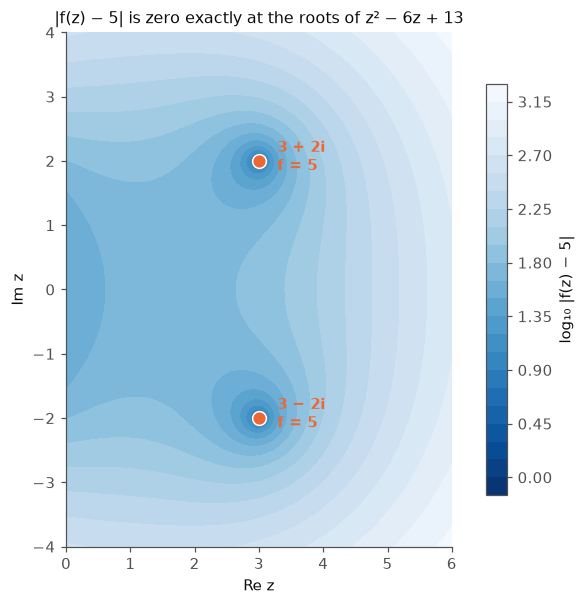

In [3]:
X, Y = np.meshgrid(np.linspace(0, 6, 400), np.linspace(-4, 4, 400))
Z = X + 1j*Y
F = np.abs(Z**4 - 4*Z**3 + 4*Z**2 + 8*Z + 44 - 5)
fig, ax = plt.subplots(figsize=(6.6, 5.6)); ax.grid(False)
im = ax.contourf(X, Y, np.log10(F + 1e-3), levels=30, cmap="Blues_r")
for z in [3 + 2j, 3 - 2j]:
    ax.plot(z.real, z.imag, "o", color=ORANGE, ms=9, mec="white")
    ax.annotate(f"{z.real:g} {'+' if z.imag > 0 else '−'} 2i\nf = 5", (z.real, z.imag), xytext=(12, -6),
                textcoords="offset points", color=ORANGE, fontsize=10, weight="bold")
ax.set_aspect("equal"); ax.set_xlabel("Re z"); ax.set_ylabel("Im z")
fig.colorbar(im, ax=ax, shrink=0.8, label="log₁₀ |f(z) − 5|")
ax.set_title("|f(z) − 5| is zero exactly at the roots of z² − 6z + 13", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 2. Geometric Meaning: Every Complex Number Is a Point

**Argand's idea:** a complex number $a + ib$ carries exactly the same information as the point $(a, b)$. In $(2, 3)$ a comma separates 2 and 3. In $2 + 3i$ the "$+\,i$" separates them. So every complex number can be drawn as a point, and every point can be named by a complex number.

He also argued that if vectors can be used in geometry, complex numbers can be too. That one idea let complex numbers start solving **geometry** problems, on top of the algebra and trigonometry problems they already handled.

### The Argand plane (complex plane)
- The plane you called the $xy$-plane in coordinate geometry is called the **Argand plane** or **complex plane** in this chapter.
- The horizontal axis is the **real axis**. All purely real numbers ($2$, $4$, $-3$, …) lie on it.
- The vertical axis is the **imaginary axis**. All purely imaginary numbers ($2i$, $-i$, …) lie on it.
- The origin $O$ is $0 + 0i$. It is the only point on **both** axes, matching Lecture 1: $0$ is the only number that is both purely real and purely imaginary.
- There are infinitely many points, so there are infinitely many complex numbers, one for each point.

**Three ways to say the same thing:**
$$\underbrace{P(a, b)}_{\text{coordinates}} \quad\longleftrightarrow\quad \underbrace{z = a + ib}_{\text{complex number}} \quad\longleftrightarrow\quad \underbrace{\vec{OP} = a\,\hat\imath + b\,\hat\jmath}_{\text{position vector}}$$

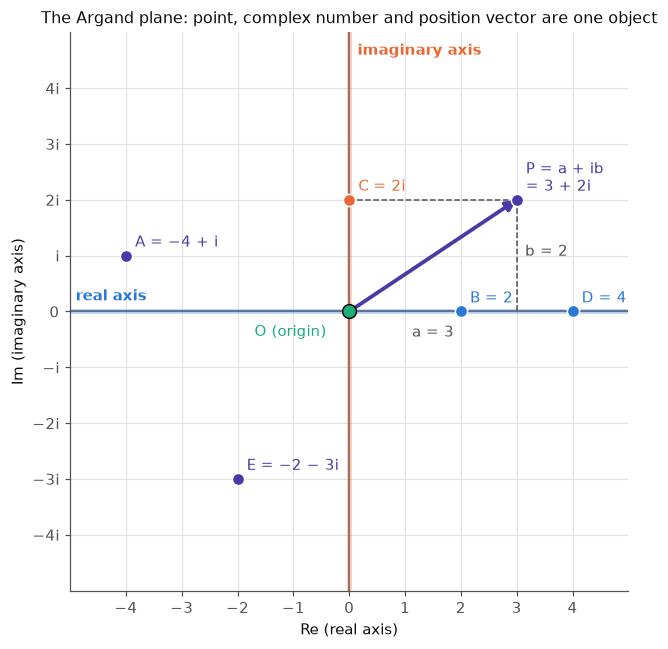

In [4]:
pts = {"P = a + ib\n= 3 + 2i": 3+2j, "A = −4 + i": -4+1j, "B = 2": 2+0j, "C = 2i": 2j, "D = 4": 4+0j, "E = −2 − 3i": -2-3j}
fig, ax = plt.subplots(figsize=(7, 6)); argand(ax, lim=5)
ax.axhline(0, color=BLUE, lw=3, alpha=0.35); ax.axvline(0, color=ORANGE, lw=3, alpha=0.35)
ax.text(-4.9, 0.2, "real axis", color=BLUE, weight="bold")
ax.text(0.15, 4.6, "imaginary axis", color=ORANGE, weight="bold")
arrow(ax, 0, 3+2j, VIOLET, lw=2.5)
ax.plot([3, 3], [0, 2], color=INK2, ls="--", lw=1); ax.plot([0, 3], [2, 2], color=INK2, ls="--", lw=1)
ax.text(1.5, -0.45, "a = 3", ha="center", color=INK2); ax.text(3.15, 1.0, "b = 2", color=INK2)
for lab, z in pts.items():
    c = BLUE if z.imag == 0 else ORANGE if z.real == 0 else VIOLET
    ax.plot(z.real, z.imag, "o", color=c, ms=8, mec="white", zorder=5)
    ax.annotate(lab, (z.real, z.imag), xytext=(6, 6), textcoords="offset points", fontsize=9.5, color=c)
ax.plot(0, 0, "o", color=AQUA, ms=9, mec=INK, zorder=6); ax.annotate("O (origin)", (0, 0), xytext=(-62, -16), textcoords="offset points", color=AQUA)
ax.set_title("The Argand plane: point, complex number and position vector are one object", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 3. Conjugate of a Complex Number

**Definition.** For $z = a + ib$, flip the sign **in front of the imaginary part**:
$$\boxed{\bar z = a - ib}$$
Read $\bar z$ as **"z bar"** or "conjugate of $z$". Other notations you may see in books are $z^*$ (a small star) and $z^c$. The bar and the star are the common ones.

| $z$ | $\bar z$ | why |
|---|---|---|
| $3 + 4i$ | $3 - 4i$ | $+$ becomes $-$ |
| $-2 - 9i$ | $-2 + 9i$ | $-$ becomes $+$. The real part's sign does **not** change |
| $3i$ | $-3i$ | $0 + 3i \to 0 - 3i$ |
| $5$ | $5$ | $5 + 0i \to 5 - 0i$, which is the same thing |
| $0$ | $0$ | |

**Observation:** a purely real number is its own conjugate. Conversely, if $z = \bar z$ then $b = -b$, so $b = 0$:
$$\boxed{z = \bar z \iff z \text{ is purely real}}$$

> Complex numbers **cannot be compared** with $<$ or $>$. Asking whether $3 + 4i$ is bigger than $2 - i$ has no meaning. The lecturer mentions this briefly, and it is why the chapter talks about *equality* but never *inequality* of complex numbers.

In [5]:
for z in [3 + 4j, -2 - 9j, 3j, 5 + 0j, 0j]:
    print(f"z = {z!s:>9}   z̄ = {z.conjugate()!s:>9}   z == z̄ ? {z == z.conjugate()}")

z =    (3+4j)   z̄ =    (3-4j)   z == z̄ ? False
z =   (-2-9j)   z̄ =   (-2+9j)   z == z̄ ? False
z =        3j   z̄ =       -3j   z == z̄ ? False
z =    (5+0j)   z̄ =    (5-0j)   z == z̄ ? True
z =        0j   z̄ =       -0j   z == z̄ ? True


### Conjugate = mirror image in the real axis
Plot $z = 4 + 3i$ and $\bar z = 4 - 3i$. The real part stays the same and the imaginary part flips sign, so **$z$ and $\bar z$ are mirror images of each other in the real axis**. Use this in geometry questions.

The animation moves $z$ around a path. Its conjugate follows as the reflection. The two meet exactly when $z$ crosses the real axis, the only places where $z = \bar z$.

In [6]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=72); argand(ax, lim=5)
ax.axhline(0, color=BLUE, lw=6, alpha=0.18)
ax.text(4.9, 0.2, "mirror", color=BLUE, ha="right", fontsize=10)
s = np.linspace(0, 2*np.pi, 300)
path = 1 + 2.5*np.cos(s) + 1j*(3.2*np.sin(s) + 0.6*np.sin(2*s))
ax.plot(path.real, path.imag, color=VIOLET, lw=1, alpha=0.25); ax.plot(path.real, -path.imag, color=ORANGE, lw=1, alpha=0.25)
vz, = ax.plot([], [], color=VIOLET, lw=2.5); vc, = ax.plot([], [], color=ORANGE, lw=2.5)
dz, = ax.plot([], [], "o", color=VIOLET, ms=9); dc, = ax.plot([], [], "o", color=ORANGE, ms=9)
link, = ax.plot([], [], color=INK2, lw=1, ls=":")
tz = ax.text(0, 0, "", color=VIOLET, fontsize=11, weight="bold"); tc = ax.text(0, 0, "", color=ORANGE, fontsize=11, weight="bold")
info = ax.text(-4.8, -4.7, "", fontsize=10)
N = 48
def update(f):
    z = path[int(f/N*len(path)) % len(path)]; w = z.conjugate()
    vz.set_data([0, z.real], [0, z.imag]); vc.set_data([0, w.real], [0, w.imag])
    dz.set_data([z.real], [z.imag]); dc.set_data([w.real], [w.imag]); link.set_data([z.real, w.real], [z.imag, w.imag])
    tz.set_position((z.real + 0.2, z.imag + 0.2)); tz.set_text("z")
    tc.set_position((w.real + 0.2, w.imag - 0.5)); tc.set_text("z̄")
    info.set_text(f"z = {z.real:+.1f} {z.imag:+.1f}i     z̄ = {w.real:+.1f} {w.imag:+.1f}i")
    return vz, vc, dz, dc, link, tz, tc, info
ax.set_title("z̄ is the reflection of z in the real axis", fontsize=11)
anim = animation.FuncAnimation(fig, update, frames=N, interval=110, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

### Properties of the conjugate
Let $z = a + ib$, $z_1 = a_1 + ib_1$, $z_2 = a_2 + ib_2$.

| # | Property | In words |
|---|---|---|
| 1 | $\bar z = a - ib$ | definition |
| 2 | $z = \bar z \iff z$ is purely real | |
| 3 | $z$ and $\bar z$ are mirror images in the real axis | |
| 4 | $\overline{\bar z} = z$ | conjugating twice undoes itself |
| 5 | $\overline{z_1 \pm z_2} = \bar z_1 \pm \bar z_2$ | bar passes through $+$ and $-$ |
| 6 | $\overline{z_1 z_2} = \bar z_1\,\bar z_2$ | bar passes through $\times$ |
| 7 | $\overline{\left(\dfrac{z_1}{z_2}\right)} = \dfrac{\bar z_1}{\bar z_2}$, with $z_2 \ne 0$ | bar passes through $\div$ |
| 8 | $z + \bar z = 2\operatorname{Re}(z)$, $\quad z - \bar z = 2i\operatorname{Im}(z)$ | |

**Property 4.** $z = a + ib \to \bar z = a - ib \to \overline{\bar z} = a + ib = z$. You apply an effect, then reverse it.

**Property 5: proof.**
$$z_1 + z_2 = (a_1 + a_2) + i(b_1 + b_2) \;\Rightarrow\; \overline{z_1 + z_2} = (a_1 + a_2) - i(b_1 + b_2)$$
$$\bar z_1 + \bar z_2 = (a_1 - ib_1) + (a_2 - ib_2) = (a_1 + a_2) - i(b_1 + b_2)$$
The right sides are identical, so the left sides are equal. $\blacksquare$ Subtraction works the same way.

It extends to any number of terms by applying it two at a time:
$$\overline{z_1 + z_2 + \cdots + z_n} = \bar z_1 + \bar z_2 + \cdots + \bar z_n$$

**Property 6: proof.**
$$z_1 z_2 = (a_1a_2 - b_1b_2) + i(a_1b_2 + a_2b_1) \;\Rightarrow\; \overline{z_1z_2} = (a_1a_2 - b_1b_2) - i(a_1b_2 + a_2b_1)$$
$$\bar z_1\,\bar z_2 = (a_1 - ib_1)(a_2 - ib_2) = a_1a_2 - ia_1b_2 - ia_2b_1 + i^2 b_1b_2 = (a_1a_2 - b_1b_2) - i(a_1b_2 + a_2b_1)$$
Same right sides, so they are equal. $\blacksquare$ Likewise $\overline{z_1z_2\cdots z_n} = \bar z_1\bar z_2\cdots\bar z_n$.

**Property 7** is **homework** in the lecture. Prove it the same way, writing $z_1 = a_1 + ib_1$ and $z_2 = a_2 + ib_2$. The denominator can never be $0$: dividing by zero leaves the answer undefined ("silence").

**Property 8.**
$$(a + ib) + (a - ib) = 2a = 2\operatorname{Re}(z), \qquad (a + ib) - (a - ib) = 2ib = 2i\operatorname{Im}(z)$$
A common slip is to forget the $i$ in $z - \bar z = 2i\,b$. The imaginary part is $b$, not $ib$.

In [7]:
z, z1, z2, z3 = rand_z(), rand_z(), rand_z(), rand_z()
c = np.conj
check("P4  conj(conj z) = z               ", c(c(z)), z)
check("P5  conj(z1 + z2) = z̄1 + z̄2         ", c(z1 + z2), c(z1) + c(z2))
check("P5  conj(z1 − z2) = z̄1 − z̄2         ", c(z1 - z2), c(z1) - c(z2))
check("P5  conj(z1 + z2 + z3) = z̄1 + z̄2 + z̄3", c(z1 + z2 + z3), c(z1) + c(z2) + c(z3))
check("P6  conj(z1 z2) = z̄1 z̄2            ", c(z1*z2), c(z1)*c(z2))
check("P6  conj(z1 z2 z3) = z̄1 z̄2 z̄3       ", c(z1*z2*z3), c(z1)*c(z2)*c(z3))
check("P7  conj(z1 / z2) = z̄1 / z̄2         ", c(z1/z2), c(z1)/c(z2))
check("P8  z + z̄ = 2 Re z                  ", z + c(z), 2*z.real)
check("P8  z − z̄ = 2i Im z                 ", z - c(z), 2j*z.imag)

P4  conj(conj z) = z               :  holds on 100.00% of 100,000 random samples
P5  conj(z1 + z2) = z̄1 + z̄2         :  holds on 100.00% of 100,000 random samples
P5  conj(z1 − z2) = z̄1 − z̄2         :  holds on 100.00% of 100,000 random samples
P5  conj(z1 + z2 + z3) = z̄1 + z̄2 + z̄3:  holds on 100.00% of 100,000 random samples
P6  conj(z1 z2) = z̄1 z̄2            :  holds on 100.00% of 100,000 random samples
P6  conj(z1 z2 z3) = z̄1 z̄2 z̄3       :  holds on 100.00% of 100,000 random samples
P7  conj(z1 / z2) = z̄1 / z̄2         :  holds on 100.00% of 100,000 random samples
P8  z + z̄ = 2 Re z                  :  holds on 100.00% of 100,000 random samples
P8  z − z̄ = 2i Im z                 :  holds on 100.00% of 100,000 random samples


### Pictures *(extra)*: properties 5, 6 and 8 as reflections
- **P5:** reflect the whole parallelogram for $z_1 + z_2$ in the real axis. You get the parallelogram for $\bar z_1 + \bar z_2$. Reflecting and then adding gives the same result as adding and then reflecting.
- **P6:** multiplying adds angles. Reflection negates every angle, so the angle of $\bar z_1\bar z_2$ is $-(\theta_1 + \theta_2)$, the reflection of $z_1z_2$.
- **P8:** adding $z$ and its mirror image cancels the vertical parts, leaving $2a$ on the real axis. Subtracting cancels the horizontal parts, leaving $2ib$ on the imaginary axis.

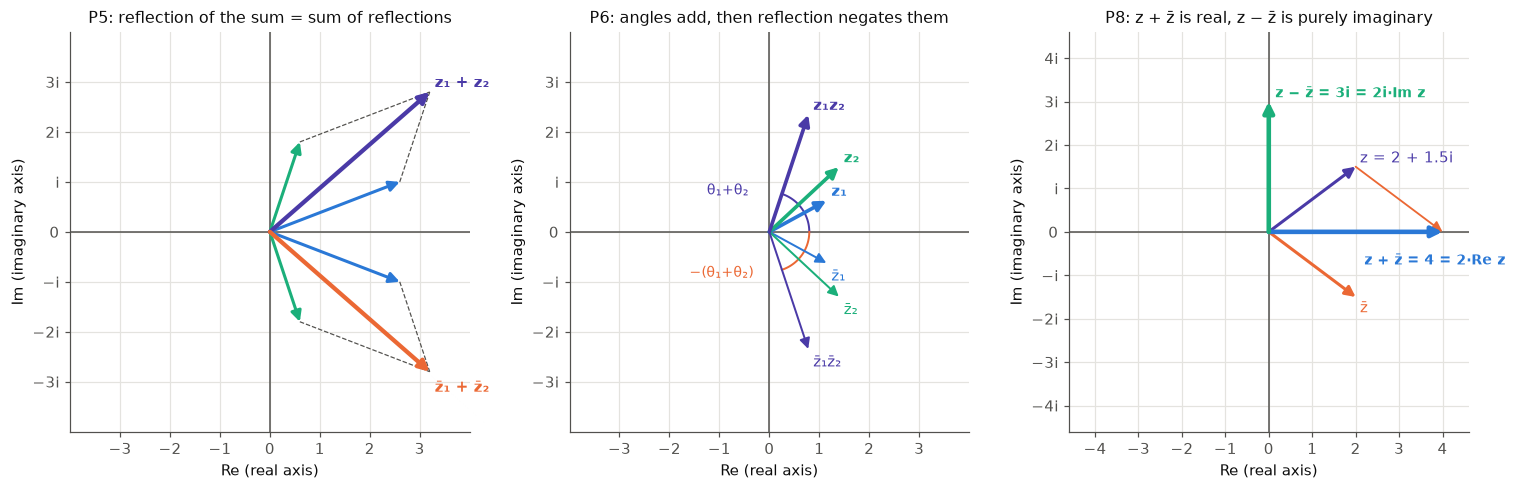

In [8]:
z1, z2 = 2.6 + 1.0j, 0.6 + 1.8j
fig, axes = plt.subplots(1, 3, figsize=(14, 4.9))

ax = axes[0]; argand(ax, lim=4)
for w, col, ls in [(1, VIOLET, "-"), (-1, ORANGE, "-")]:
    a, b = (z1, z2) if w == 1 else (z1.conjugate(), z2.conjugate())
    arrow(ax, 0, a, BLUE); arrow(ax, 0, b, AQUA); arrow(ax, 0, a + b, col, lw=2.8)
    ax.plot([a.real, (a+b).real], [a.imag, (a+b).imag], color=INK2, lw=0.8, ls="--")
    ax.plot([b.real, (a+b).real], [b.imag, (a+b).imag], color=INK2, lw=0.8, ls="--")
ax.text(3.3, 2.9, "z₁ + z₂", color=VIOLET, weight="bold"); ax.text(3.3, -3.2, "z̄₁ + z̄₂", color=ORANGE, weight="bold")
ax.set_title("P5: reflection of the sum = sum of reflections", fontsize=10.5)

ax = axes[1]; argand(ax, lim=4)
w1, w2 = 1.3*np.exp(0.5j), 1.9*np.exp(0.75j)
for a, col, lab in [(w1, BLUE, "z₁"), (w2, AQUA, "z₂"), (w1*w2, VIOLET, "z₁z₂")]:
    arrow(ax, 0, a, col, 2.4); arrow(ax, 0, a.conjugate(), col, 1.3)
    ax.text(a.real + 0.1, a.imag + 0.1, lab, color=col, weight="bold")
    ax.text(a.real + 0.1, -a.imag - 0.35, {"z₁": "z̄₁", "z₂": "z̄₂", "z₁z₂": "z̄₁z̄₂"}[lab], color=col)
th = np.linspace(0, 1.25, 60); ax.plot(0.8*np.cos(th), 0.8*np.sin(th), color=VIOLET, lw=1.3)
ax.plot(0.8*np.cos(th), -0.8*np.sin(th), color=ORANGE, lw=1.3)
ax.text(-1.25, 0.75, "θ₁+θ₂", color=VIOLET, fontsize=9); ax.text(-1.6, -0.9, "−(θ₁+θ₂)", color=ORANGE, fontsize=9)
ax.set_title("P6: angles add, then reflection negates them", fontsize=10.5)

ax = axes[2]; argand(ax, lim=4.6)
z = 2 + 1.5j
arrow(ax, 0, z, VIOLET); arrow(ax, 0, z.conjugate(), ORANGE)
arrow(ax, z, z + z.conjugate(), ORANGE, 1.2); arrow(ax, 0, z + z.conjugate(), BLUE, 3)
arrow(ax, 0, z - z.conjugate(), AQUA, 3)
ax.text(z.real + 0.1, z.imag + 0.1, "z = 2 + 1.5i", color=VIOLET); ax.text(z.real + 0.1, -z.imag - 0.35, "z̄", color=ORANGE)
ax.text(2.2, -0.75, "z + z̄ = 4 = 2·Re z", color=BLUE, weight="bold", fontsize=9)
ax.text(0.15, 3.1, "z − z̄ = 3i = 2i·Im z", color=AQUA, weight="bold", fontsize=9)
ax.set_title("P8: z + z̄ is real, z − z̄ is purely imaginary", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 4. Modulus of a Complex Number

**Definition.** The modulus of $z$, written $|z|$ and read "mod $z$", is the **distance between the origin and the point $z$** in the Argand plane.

For $z = a + ib$, the point is $(a, b)$, so by the distance formula from Class 9/10:
$$|z| = \sqrt{(a - 0)^2 + (b - 0)^2}$$
$$\boxed{|z| = \sqrt{a^2 + b^2} = \sqrt{(\operatorname{Re} z)^2 + (\operatorname{Im} z)^2}}$$
**Recipe:** square the real part, add the square of the imaginary part, take the square root.

Examples: $|3 + 4i| = 5$, $\;|-5i| = 5$, $\;|-2| = 2$, $\;|1 + i| = \sqrt2$.

In [9]:
for a, b in [(3, 4), (0, -5), (-2, 0), (1, 1), (3, -4)]:
    print(f"|{a} {'+' if b >= 0 else '−'} {abs(b)}i|  =  √(({a})² + ({b})²)  =  {abs(complex(a, b)):.4f}")

|3 + 4i|  =  √((3)² + (4)²)  =  5.0000
|0 − 5i|  =  √((0)² + (-5)²)  =  5.0000
|-2 + 0i|  =  √((-2)² + (0)²)  =  2.0000
|1 + 1i|  =  √((1)² + (1)²)  =  1.4142
|3 − 4i|  =  √((3)² + (-4)²)  =  5.0000


### Picture *(extra)*: modulus is a distance, so equal modulus means a circle
$|3 + 4i| = 5$ is the hypotenuse of a $3$–$4$–$5$ right triangle. Every complex number with modulus $5$ lies at distance $5$ from $O$, which is the circle of radius $5$. Notice $3 + 4i$, $3 - 4i$, $-3 + 4i$, $5$, $-5i$ all sit on it.

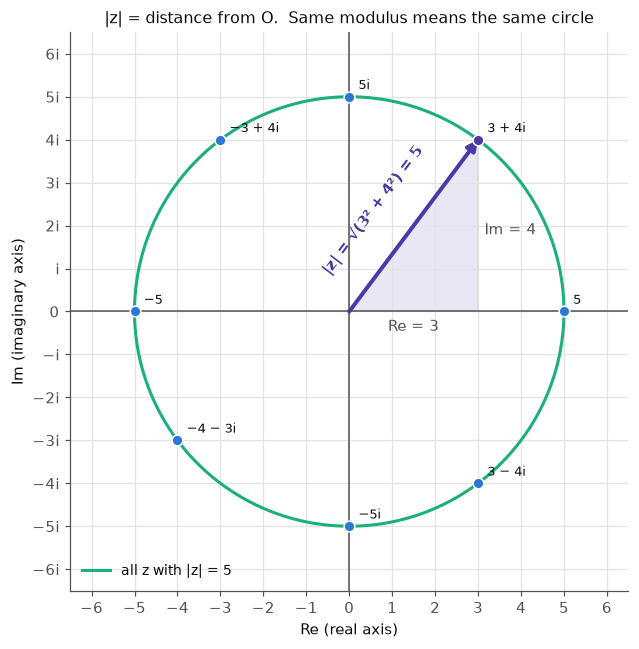

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 6)); argand(ax, lim=6.5, ticks=1)
th = np.linspace(0, 2*np.pi, 400); ax.plot(5*np.cos(th), 5*np.sin(th), color=AQUA, lw=2, label="all z with |z| = 5")
z = 3 + 4j
ax.fill([0, 3, 3], [0, 0, 4], color=VIOLET, alpha=0.12)
arrow(ax, 0, z, VIOLET, 2.6)
ax.text(1.5, -0.45, "Re = 3", ha="center", color=INK2); ax.text(3.15, 1.8, "Im = 4", color=INK2)
ax.text(0.55, 2.35, "|z| = √(3² + 4²) = 5", color=VIOLET, rotation=53, fontsize=10, weight="bold", ha="center", va="center")
for w, lab in [(3+4j, "3 + 4i"), (3-4j, "3 − 4i"), (-3+4j, "−3 + 4i"), (-4-3j, "−4 − 3i"),
               (5+0j, "5"), (-5j, "−5i"), (5j, "5i"), (-5+0j, "−5")]:
    ax.plot(w.real, w.imag, "o", color=BLUE if w != z else VIOLET, ms=7, mec="white", zorder=5)
    ax.annotate(lab, (w.real, w.imag), xytext=(6, 5), textcoords="offset points", fontsize=8.5)
ax.legend(frameon=False, loc="lower left", fontsize=9)
ax.set_title("|z| = distance from O.  Same modulus means the same circle", fontsize=10.5)
plt.tight_layout(); plt.show()

### Properties of the modulus

| # | Property | Note |
|---|---|---|
| 1 | $\lvert z\rvert = \sqrt{a^2 + b^2}$ | definition |
| 2 | $\lvert z\rvert = \lvert\bar z\rvert$ | $\sqrt{a^2 + (-b)^2} = \sqrt{a^2 + b^2}$. Mirror images are the same distance from $O$ |
| 3 | $z\,\bar z = \lvert z\rvert^2$ | very important, and asked often |
| 4 | $\lvert z_1 \pm z_2\rvert \ne \lvert z_1\rvert \pm \lvert z_2\rvert$ **in general** | **trap!** The conjugate rule does *not* carry over |
| 5 | $\lvert z_1 z_2\rvert = \lvert z_1\rvert\,\lvert z_2\rvert$, and in general $\lvert z_1 z_2\cdots z_n\rvert = \lvert z_1\rvert\cdots\lvert z_n\rvert$ | proof promised for the next lecture |
| 6 | $\left\lvert \dfrac{z_1}{z_2}\right\rvert = \dfrac{\lvert z_1\rvert}{\lvert z_2\rvert}$, with $z_2 \ne 0$ | |
| 7 | $\lvert z^n\rvert = \lvert z\rvert^n$ | follows from 5 with all $z_k = z$ |

**Property 3: proof.** Use $(x + y)(x - y) = x^2 - y^2$:
$$z\bar z = (a + ib)(a - ib) = a^2 - i^2b^2 = a^2 + b^2 = |z|^2 \quad\blacksquare$$
This is why the division trick in Lecture 1 works. Multiplying the denominator by its conjugate turns it into the real number $|z_2|^2$:
$$\frac{z_1}{z_2} = \frac{z_1\bar z_2}{z_2\bar z_2} = \frac{z_1\bar z_2}{|z_2|^2}$$

**Property 4: the trap.** Students see $\overline{z_1 + z_2} = \bar z_1 + \bar z_2$ and wrongly write $|z_1 + z_2| = |z_1| + |z_2|$. This is **not true in general**. It can hold in special cases, but you cannot use it as a rule. Example: $|1 + (-1)| = 0$, but $|1| + |-1| = 2$.

**Property 7 from Property 5:**
$$|z^n| = |\underbrace{z\cdot z\cdots z}_{n}| = \underbrace{|z|\cdot|z|\cdots|z|}_{n} = |z|^n$$
You can apply the power first and then the mod, or the mod first and then the power. The order makes no difference.

In [11]:
z, z1, z2 = rand_z(), rand_z(), rand_z()
check("M2  |z| = |z̄|                 ", np.abs(z), np.abs(np.conj(z)))
check("M3  z z̄ = |z|²                ", z*np.conj(z), np.abs(z)**2)
check("M4  |z1 + z2| = |z1| + |z2| ?? ", np.abs(z1 + z2), np.abs(z1) + np.abs(z2))
check("M5  |z1 z2| = |z1| |z2|        ", np.abs(z1*z2), np.abs(z1)*np.abs(z2))
check("M6  |z1 / z2| = |z1| / |z2|    ", np.abs(z1/z2), np.abs(z1)/np.abs(z2))
check("M7  |z⁷| = |z|⁷                ", np.abs(z**7), np.abs(z)**7)
print("\nM4 is false almost always. It holds only in the special case when z1 and z2 point the same way:")
print("   |1 + (−1)| =", abs(1 + -1), "  but  |1| + |−1| =", abs(1) + abs(-1))
print("   |(1+i) + (2+2i)| =", abs(3 + 3j), " =  |1+i| + |2+2i| =", abs(1 + 1j) + abs(2 + 2j), "  (same direction)")

M2  |z| = |z̄|                 :  holds on 100.00% of 100,000 random samples
M3  z z̄ = |z|²                :  holds on 100.00% of 100,000 random samples
M4  |z1 + z2| = |z1| + |z2| ?? :  holds on 0.30% of 100,000 random samples
M5  |z1 z2| = |z1| |z2|        :  holds on 100.00% of 100,000 random samples
M6  |z1 / z2| = |z1| / |z2|    :  holds on 100.00% of 100,000 random samples
M7  |z⁷| = |z|⁷                :  holds on 100.00% of 100,000 random samples

M4 is false almost always. It holds only in the special case when z1 and z2 point the same way:
   |1 + (−1)| = 0   but  |1| + |−1| = 2
   |(1+i) + (2+2i)| = 4.242640687119285  =  |1+i| + |2+2i| = 4.242640687119286   (same direction)


### Animation *(extra)*: why $|z_1 + z_2| \ne |z_1| + |z_2|$
$z_1$, $z_2$ and $z_1 + z_2$ form a **triangle**: $z_1$ from $O$, then $z_2$ placed tip to tail, then the sum closes it. In a triangle one side is never longer than the other two combined, so
$$|z_1 + z_2| \le |z_1| + |z_2|$$
with equality **only** when the triangle flattens out with $z_2$ pointing the same way as $z_1$. That is the "special case" the lecturer mentions. (This is the **triangle inequality**, which comes up in later lectures.)

In the animation $z_2$ keeps its length but turns. The right panel tracks $|z_1 + z_2|$ against the constant $|z_1| + |z_2|$. The two touch only once per turn.

In [12]:
z1, r2 = 2.0 + 0.8j, 1.4
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), dpi=72, gridspec_kw=dict(width_ratios=[1, 1.15]))
ax = axes[0]; argand(ax, lim=4.2)
th = np.linspace(0, 2*np.pi, 300); ax.plot(z1.real + r2*np.cos(th), z1.imag + r2*np.sin(th), color=GRID, lw=1.5)
a1, = ax.plot([0, z1.real], [0, z1.imag], color=BLUE, lw=3, label=f"z₁   |z₁| = {abs(z1):.2f}")
a2, = ax.plot([], [], color=ORANGE, lw=3, label=f"z₂   |z₂| = {r2}")
a3, = ax.plot([], [], color=VIOLET, lw=3, label="z₁ + z₂")
ax.legend(frameon=False, loc="lower left", fontsize=9)
ax.set_title("triangle: z₁, then z₂ tip to tail, then the sum", fontsize=10.5)
ax2 = axes[1]
phis = np.linspace(0, 2*np.pi, 300); S = np.abs(z1 + r2*np.exp(1j*phis))
ax2.plot(np.degrees(phis), S, color=VIOLET, lw=1, alpha=0.3)
ax2.axhline(abs(z1) + r2, color=INK2, ls="--", lw=1.4, label="|z₁| + |z₂|  (constant)")
ax2.axvline(np.degrees(np.angle(z1)), color=AQUA, lw=1, ls=":")
ax2.text(np.degrees(np.angle(z1)) + 4, 1.0, "z₂ points the same\nway as z₁: equality", color=AQUA, fontsize=9)
tr, = ax2.plot([], [], color=VIOLET, lw=2.5, label="|z₁ + z₂|"); dot, = ax2.plot([], [], "o", color=VIOLET, ms=8)
ax2.set_xlim(0, 360); ax2.set_ylim(0, 4.3); ax2.set_xticks(range(0, 361, 90))
ax2.set_xlabel("direction of z₂ (degrees)"); ax2.legend(frameon=False, loc="lower right", fontsize=9)
ax2.set_title("|z₁ + z₂| ≤ |z₁| + |z₂|, equal at only one direction", fontsize=10.5)
N = 48
def update(f):
    phi = 2*np.pi*f/N; z2 = r2*np.exp(1j*phi); s = z1 + z2
    a2.set_data([z1.real, s.real], [z1.imag, s.imag]); a3.set_data([0, s.real], [0, s.imag])
    k = np.searchsorted(phis, phi); tr.set_data(np.degrees(phis[:k + 1]), S[:k + 1]); dot.set_data([np.degrees(phi)], [abs(s)])
    return a2, a3, tr, dot
anim = animation.FuncAnimation(fig, update, frames=N, interval=110, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

### Picture *(extra)*: $|z_1z_2| = |z_1||z_2|$ and $|z^n| = |z|^n$
Multiplying **multiplies lengths** (and adds angles, as seen in Lecture 1). So the powers of $z$ have lengths $|z|, |z|^2, |z|^3, \dots$ If $|z| > 1$ they spiral outward, if $|z| < 1$ they spiral inward, and if $|z| = 1$ they stay on the unit circle.

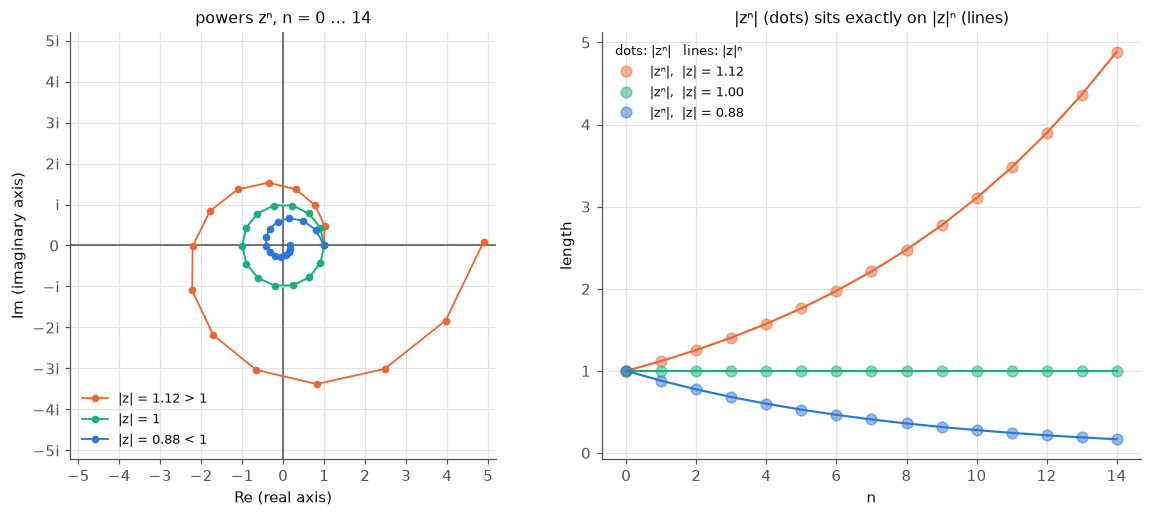

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ax = axes[0]; argand(ax, lim=5.2)
th = np.linspace(0, 2*np.pi, 300); ax.plot(np.cos(th), np.sin(th), color=GRID, lw=1.5)
for z, col, lab in [(1.12*np.exp(0.45j), ORANGE, "|z| = 1.12 > 1"), (np.exp(0.45j), AQUA, "|z| = 1"), (0.88*np.exp(0.45j), BLUE, "|z| = 0.88 < 1")]:
    P = z**np.arange(0, 15)
    ax.plot(P.real, P.imag, "o-", color=col, ms=4, lw=1.2, label=lab)
ax.legend(frameon=False, fontsize=8.5, loc="lower left"); ax.set_title("powers zⁿ, n = 0 … 14", fontsize=10.5)

ax = axes[1]
n = np.arange(0, 15)
for z, col in [(1.12*np.exp(0.45j), ORANGE), (np.exp(0.45j), AQUA), (0.88*np.exp(0.45j), BLUE)]:
    ax.plot(n, np.abs(z**n), "o", color=col, ms=7, alpha=0.5, label=f"|zⁿ|,  |z| = {abs(z):.2f}")
    ax.plot(n, np.abs(z)**n, "-", color=col, lw=1.4)
ax.set_xlabel("n"); ax.set_ylabel("length")
ax.legend(frameon=False, fontsize=8.5, title="dots: |zⁿ|   lines: |z|ⁿ", title_fontsize=8.5)
ax.set_title("|zⁿ| (dots) sits exactly on |z|ⁿ (lines)", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## Summary

| Idea | Result |
|---|---|
| Polynomial at $a + ib$ | square $(x - a) = ib$ to get a quadratic $= 0$, divide, and the **remainder** is the answer |
| Geometry | $z = a + ib \leftrightarrow$ point $(a, b)$ $\leftrightarrow$ position vector $a\hat\imath + b\hat\jmath$ on the **Argand plane** |
| Axes | real numbers on the real axis, purely imaginary numbers on the imaginary axis, $0$ at the origin |
| Conjugate | $\bar z = a - ib$, the mirror image in the real axis. $z = \bar z \iff z$ real. $\overline{\bar z} = z$ |
| Bar passes through | $+,\ -,\ \times,\ \div$: $\;\overline{z_1 \pm z_2} = \bar z_1 \pm \bar z_2$, $\;\overline{z_1z_2} = \bar z_1\bar z_2$, $\;\overline{z_1/z_2} = \bar z_1/\bar z_2$ |
| $z \pm \bar z$ | $z + \bar z = 2\operatorname{Re} z$, $\quad z - \bar z = 2i\operatorname{Im} z$ |
| Modulus | $\lvert z\rvert = \sqrt{a^2 + b^2}$ = distance from $O$. $\lvert z\rvert = \lvert\bar z\rvert$. $z\bar z = \lvert z\rvert^2$ |
| Mod passes through | $\times,\ \div$, powers: $\lvert z_1z_2\rvert = \lvert z_1\rvert\lvert z_2\rvert$, $\lvert z_1/z_2\rvert = \lvert z_1\rvert/\lvert z_2\rvert$, $\lvert z^n\rvert = \lvert z\rvert^n$ |
| **Trap** | mod does **not** pass through $\pm$: $\lvert z_1 + z_2\rvert \ne \lvert z_1\rvert + \lvert z_2\rvert$ in general (only $\le$) |

**Homework from the lecture:**
1. Prove conjugate property 7: $\overline{(z_1/z_2)} = \bar z_1/\bar z_2$.
2. Try proving modulus property 5, $|z_1z_2| = |z_1||z_2|$, with $z_1 = a_1 + ib_1$, $z_2 = a_2 + ib_2$. The lecturer proves it next lecture.
3. A JEE-level question to attempt before Lecture 3: if $|z_1| = 1$, $|z_2| = 2$, $|z_3| = 3$ and $|9z_1z_2 + 4z_1z_3 + z_2z_3| = 12$, find $|z_1 + z_2 + z_3|$. *(Solved at the start of Lecture 3. The answer is $2$.)*

---
## Practice *(extra)*
1. Find $f(1 - 2i)$ if $f(x) = x^3 - x^2 + 3x + 7$. *(Hint: $x - 1 = -2i$)*
2. If $z = 2 - 3i$, find $z\bar z$, $z + \bar z$ and $z - \bar z$.
3. Find $\left|\dfrac{(3 + 4i)(1 - i)^4}{(1 + i\sqrt3)^2}\right|$ **without** multiplying anything out.
4. Find $z$ if $\bar z = z$ and $|z| = 7$.

<details>
<summary>Answers (open after attempting)</summary>

1. $(x - 1)^2 = -4 \Rightarrow x^2 - 2x + 5 = 0$. Dividing, $x^3 - x^2 + 3x + 7 = (x^2 - 2x + 5)(x + 1) + 2$, so $f(1 - 2i) = 2$.
2. $z\bar z = |z|^2 = 4 + 9 = 13$, $\;z + \bar z = 4$, $\;z - \bar z = -6i$.
3. Use $|z_1z_2| = |z_1||z_2|$, $|z^n| = |z|^n$ and $|z_1/z_2| = |z_1|/|z_2|$: $\dfrac{5\cdot(\sqrt2)^4}{2^2} = \dfrac{5\cdot4}{4} = 5$.
4. $\bar z = z$ means $z$ is real, and $|z| = 7$ means $z = 7$ or $z = -7$.
</details>

In [14]:
# Checks for the practice set
x = 1 - 2j; print("1:", x**3 - x**2 + 3*x + 7, "   remainder:", np.polydiv([1, -1, 3, 7], [1, -2, 5])[1])
z = 2 - 3j; print("2:", z*z.conjugate(), z + z.conjugate(), z - z.conjugate())
print("3:", round(abs((3 + 4j)*(1 - 1j)**4/(1 + 1j*np.sqrt(3))**2), 12))
print("4:", [w for w in [7 + 0j, -7 + 0j] if w == w.conjugate() and abs(w) == 7])

1: (2+0j)    remainder: [2.]
2: (13+0j) (4+0j) -6j
3: 5.0
4: [(7+0j), (-7+0j)]
